# Market Risk Analytics Platform

## Notebook 02 — Portfolio Construction and P&L Analysis

### Objectives

This notebook constructs a diversified multi-asset portfolio using the clean market data generated by Notebook 01.

It performs:

- validation of Notebook 01 dependencies;
- definition of portfolio allocations;
- conversion of allocations into asset positions;
- calculation of daily market values;
- daily and cumulative P&L analysis;
- portfolio return analysis;
- position-level P&L attribution;
- exposure and concentration analysis;
- generation of reusable datasets for downstream risk models.

### Pipeline dependencies

This notebook depends on the successful execution of:

- Notebook 01 — Data Collection, Validation and Market Analysis.

The outputs generated here will be consumed by:

- Notebook 03 — VaR and Expected Shortfall;
- Notebook 04 — Backtesting and Stress Testing;
- Notebook 05 — Risk Factors and Reporting.

## Environnement et dépendances

### Monter Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Définir les chemins

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/market-risk-analytics"
)

CONFIG_DIR = PROJECT_ROOT / "config"
DATA_DIR = PROJECT_ROOT / "data"
DATA_PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for directory in [
    CONFIG_DIR,
    DATA_PROCESSED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    SRC_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /content/drive/MyDrive/market-risk-analytics


### Importer les bibliothèques

In [ ]:
from datetime import datetime, timezone
import hashlib
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

TRADING_DAYS_PER_YEAR = 252
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## Vérification de la dépendance au notebook 1

### Définir les fichiers requis

In [ ]:
NOTEBOOK_01_FILES = {
    "prices": (
        DATA_PROCESSED_DIR
        / "market_prices.parquet"
    ),
    "returns": (
        DATA_PROCESSED_DIR
        / "market_returns.parquet"
    ),
    "asset_reference": (
        CONFIG_DIR
        / "asset_reference.csv"
    ),
    "manifest": (
        CONFIG_DIR
        / "pipeline_manifest.json"
    ),
}

### Vérifier leur présence

In [ ]:
def validate_required_files(
    required_files: dict[str, Path],
) -> None:
    """Check that all upstream files exist and are non-empty."""

    missing_files = [
        file_path
        for file_path in required_files.values()
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Notebook 01 must be executed first. "
            f"Missing files: {missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files.values()
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            f"Empty dependency files detected: {empty_files}"
        )

    print("All Notebook 01 dependency files are available.")


validate_required_files(NOTEBOOK_01_FILES)

All Notebook 01 dependency files are available.


### Charger et vérifier le manifeste

In [ ]:
with open(
    NOTEBOOK_01_FILES["manifest"],
    "r",
    encoding="utf-8",
) as manifest_file:
    notebook_01_manifest = json.load(
        manifest_file
    )

if notebook_01_manifest.get("status") != "SUCCESS":
    raise RuntimeError(
        "Notebook 01 did not complete successfully."
    )

expected_producer = (
    "01_data_collection_and_market_analysis.ipynb"
)

if (
    notebook_01_manifest.get("producer_notebook")
    != expected_producer
):
    raise RuntimeError(
        "Unexpected producer notebook in pipeline manifest."
    )

print("Notebook 01 manifest successfully validated.")
print(
    "Data period:",
    notebook_01_manifest["actual_start_date"],
    "to",
    notebook_01_manifest["actual_end_date"],
)
print(
    "Assets:",
    notebook_01_manifest["assets"],
)

Notebook 01 manifest successfully validated.
Data period: 2018-01-02 to 2026-07-29
Assets: ['US_EQUITY', 'EUROPE_EQUITY', 'US_TREASURY', 'CORPORATE_BOND', 'GOLD', 'EURUSD']


### Vérifier les empreintes des fichiers

In [ ]:
def calculate_file_hash(
    file_path: Path,
) -> str:
    """Calculate the SHA-256 hash of a file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(8192),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [ ]:
expected_hashes = notebook_01_manifest.get(
    "file_hashes",
    {},
)

files_to_verify = {
    "market_prices.parquet":
        NOTEBOOK_01_FILES["prices"],

    "market_returns.parquet":
        NOTEBOOK_01_FILES["returns"],

    "asset_reference.csv":
        NOTEBOOK_01_FILES["asset_reference"],
}

hash_validation_results = {}

for file_name, file_path in files_to_verify.items():
    calculated_hash = calculate_file_hash(file_path)
    expected_hash = expected_hashes.get(file_name)

    hash_validation_results[file_name] = {
        "expected_hash": expected_hash,
        "calculated_hash": calculated_hash,
        "is_valid": (
            expected_hash == calculated_hash
            if expected_hash is not None
            else None
        ),
    }

hash_validation_results

{'market_prices.parquet': {'expected_hash': '819c31cbc8bd05bac8330bec6d82245010625ba55b6d7f10e614b1c9761543f2',
  'calculated_hash': '819c31cbc8bd05bac8330bec6d82245010625ba55b6d7f10e614b1c9761543f2',
  'is_valid': True},
 'market_returns.parquet': {'expected_hash': 'fa9a0a614d0e8b3c644aa1a8fa4c11f60279a12f8e1a2b5a1625d5578a22b0a6',
  'calculated_hash': 'fa9a0a614d0e8b3c644aa1a8fa4c11f60279a12f8e1a2b5a1625d5578a22b0a6',
  'is_valid': True},
 'asset_reference.csv': {'expected_hash': 'c53b40a8811f4e5c06787811f006bcb5e81aef90f29371b0b902bbff10fcab11',
  'calculated_hash': 'c53b40a8811f4e5c06787811f006bcb5e81aef90f29371b0b902bbff10fcab11',
  'is_valid': True}}

In [ ]:
invalid_hashes = [
    file_name
    for file_name, result
    in hash_validation_results.items()
    if result["is_valid"] is False
]

if invalid_hashes:
    raise RuntimeError(
        "Some Notebook 01 files were modified after "
        f"generation: {invalid_hashes}"
    )

print("Dependency integrity checks passed.")

Dependency integrity checks passed.


## Chargement des données

### Charger les prix, rendements et références

In [ ]:
prices = pd.read_parquet(
    NOTEBOOK_01_FILES["prices"]
)

asset_returns = pd.read_parquet(
    NOTEBOOK_01_FILES["returns"]
)

asset_reference = pd.read_csv(
    NOTEBOOK_01_FILES["asset_reference"],
    index_col=0,
)

prices.index = pd.to_datetime(prices.index)
asset_returns.index = pd.to_datetime(
    asset_returns.index
)

prices.index.name = "date"
asset_returns.index.name = "date"

print(f"Prices shape: {prices.shape}")
print(f"Returns shape: {asset_returns.shape}")

prices.head()

Prices shape: (2233, 6)
Returns shape: (2232, 6)


asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,235.954285,31.983484,85.827789,89.042908,125.150002,1.201158
2018-01-03,237.446762,32.108631,85.917542,89.205132,124.820000,1.206345
2018-01-04,238.447540,32.679623,85.876732,89.175629,125.459999,1.201043
2018-01-05,240.036545,33.008141,85.770699,89.146141,125.330002,1.206884
2018-01-08,240.475494,32.875175,85.729919,89.138786,125.309998,1.203746


### Contrôler l’alignement

In [ ]:
def validate_loaded_market_data(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
    asset_reference: pd.DataFrame,
) -> None:
    """Validate the market datasets loaded from Notebook 01."""

    if prices.empty:
        raise ValueError("The price dataset is empty.")

    if returns.empty:
        raise ValueError("The return dataset is empty.")

    if prices.isna().any().any():
        raise ValueError(
            "The price dataset contains missing values."
        )

    if returns.isna().any().any():
        raise ValueError(
            "The return dataset contains missing values."
        )

    if not np.isfinite(prices.to_numpy()).all():
        raise ValueError(
            "The price dataset contains infinite values."
        )

    if not np.isfinite(returns.to_numpy()).all():
        raise ValueError(
            "The return dataset contains infinite values."
        )

    if prices.le(0).any().any():
        raise ValueError(
            "The price dataset contains non-positive values."
        )

    if prices.columns.tolist() != returns.columns.tolist():
        raise ValueError(
            "Price and return columns are not aligned."
        )

    missing_reference_assets = (
        set(prices.columns)
        - set(asset_reference.index)
    )

    if missing_reference_assets:
        raise ValueError(
            "Missing asset metadata for: "
            f"{sorted(missing_reference_assets)}"
        )

    if not returns.index.isin(prices.index).all():
        raise ValueError(
            "Some return dates do not exist in price data."
        )

    print("Loaded market data validation successful.")


validate_loaded_market_data(
    prices=prices,
    returns=asset_returns,
    asset_reference=asset_reference,
)

Loaded market data validation successful.


## Définition du portefeuille

Nous allons utiliser un portefeuille initial d’une valeur de 1 000 000 €.

Même si les instruments sont principalement cotés en dollars, nous utiliserons ici une devise de reporting pédagogique unique. Dans une version plus avancée, nous ajouterons une conversion dynamique en EUR.

### Paramètres du portefeuille

In [ ]:
PORTFOLIO_NAME = "Global Multi-Asset Risk Portfolio"
REPORTING_CURRENCY = "EUR"

INITIAL_PORTFOLIO_VALUE = 1_000_000.0

PORTFOLIO_WEIGHTS = pd.Series(
    {
        "US_EQUITY": 0.25,
        "EUROPE_EQUITY": 0.20,
        "US_TREASURY": 0.20,
        "CORPORATE_BOND": 0.15,
        "GOLD": 0.10,
        "EURUSD": 0.10,
    },
    name="target_weight",
    dtype=float,
)

PORTFOLIO_WEIGHTS

,target_weight
US_EQUITY,0.250000
EUROPE_EQUITY,0.200000
US_TREASURY,0.200000
CORPORATE_BOND,0.150000
GOLD,0.100000
EURUSD,0.100000


### Valider les poids

In [ ]:
def validate_portfolio_weights(
    weights: pd.Series,
    available_assets: list[str],
    allow_short_positions: bool = False,
    tolerance: float = 1e-8,
) -> pd.Series:
    """
    Validate portfolio weights and return a normalized copy.
    """

    if weights.empty:
        raise ValueError(
            "Portfolio weights cannot be empty."
        )

    if weights.index.duplicated().any():
        raise ValueError(
            "Duplicate assets detected in portfolio weights."
        )

    if weights.isna().any():
        raise ValueError(
            "Portfolio weights contain missing values."
        )

    if not np.isfinite(weights.to_numpy()).all():
        raise ValueError(
            "Portfolio weights must be finite."
        )

    missing_assets = (
        set(weights.index)
        - set(available_assets)
    )

    if missing_assets:
        raise ValueError(
            "Portfolio assets missing from market data: "
            f"{sorted(missing_assets)}"
        )

    if (
        not allow_short_positions
        and weights.lt(0).any()
    ):
        short_assets = weights[
            weights.lt(0)
        ].index.tolist()

        raise ValueError(
            "Short positions are not allowed. "
            f"Negative weights detected for: {short_assets}"
        )

    weight_sum = float(weights.sum())

    if abs(weight_sum) < tolerance:
        raise ValueError(
            "The sum of portfolio weights cannot be zero."
        )

    normalized_weights = weights / weight_sum

    if not np.isclose(
        normalized_weights.sum(),
        1.0,
        atol=tolerance,
    ):
        raise ValueError(
            "Portfolio weights could not be normalized."
        )

    return normalized_weights


portfolio_weights = validate_portfolio_weights(
    weights=PORTFOLIO_WEIGHTS,
    available_assets=prices.columns.tolist(),
    allow_short_positions=False,
)

portfolio_weights

,target_weight
US_EQUITY,0.250000
EUROPE_EQUITY,0.200000
US_TREASURY,0.200000
CORPORATE_BOND,0.150000
GOLD,0.100000
EURUSD,0.100000


## 5. Construction des positions

Nous allons construire un portefeuille buy-and-hold :

les quantités sont déterminées à la date initiale ;

les quantités restent constantes ;

la valeur des positions évolue avec les prix de marché ;

les poids réels évoluent donc dans le temps.

Cette approche est réaliste pour analyser le P&L d’un portefeuille détenu.

### Définir la date de valorisation initiale

In [ ]:
INITIAL_VALUATION_DATE = prices.index.min()

initial_prices = prices.loc[
    INITIAL_VALUATION_DATE,
    portfolio_weights.index,
]

print(
    f"Initial valuation date: "
    f"{INITIAL_VALUATION_DATE.date()}"
)

initial_prices

Initial valuation date: 2018-01-02


,2018-01-02
US_EQUITY,235.954285
EUROPE_EQUITY,31.983484
US_TREASURY,85.827789
CORPORATE_BOND,89.042908
GOLD,125.150002
EURUSD,1.201158


### Calculer les montants investis

In [ ]:
initial_allocations = (
    portfolio_weights
    * INITIAL_PORTFOLIO_VALUE
)

initial_allocations.name = "initial_allocation"

initial_allocations

,initial_allocation
US_EQUITY,"250,000.000000"
EUROPE_EQUITY,"200,000.000000"
US_TREASURY,"200,000.000000"
CORPORATE_BOND,"150,000.000000"
GOLD,"100,000.000000"
EURUSD,"100,000.000000"


### Calculer les quantités détenues

In [ ]:
position_units = (
    initial_allocations
    / initial_prices
)

position_units.name = "units"

position_units

,units
US_EQUITY,"1,059.527274"
EUROPE_EQUITY,"6,253.227395"
US_TREASURY,"2,330.247599"
CORPORATE_BOND,"1,684.581106"
GOLD,799.041141
EURUSD,"83,252.999218"


Pour l’EUR/USD, la quantité représente ici une exposition notionnelle pédagogique au taux de change, et non un contrat FX réel.

### Construire la table des positions

In [ ]:
portfolio_positions = pd.concat(
    [
        portfolio_weights,
        initial_prices.rename("initial_price"),
        initial_allocations,
        position_units,
    ],
    axis=1,
)

portfolio_positions = portfolio_positions.join(
    asset_reference[
        [
            "ticker",
            "description",
            "risk_factor",
            "currency",
        ]
    ],
    how="left",
)

portfolio_positions["portfolio_name"] = (
    PORTFOLIO_NAME
)

portfolio_positions["reporting_currency"] = (
    REPORTING_CURRENCY
)

portfolio_positions.index.name = "asset"

portfolio_positions

,target_weight,initial_price,initial_allocation,units,ticker,description,risk_factor,currency,portfolio_name,reporting_currency
asset,,,,,,,,,,
US_EQUITY,0.250000,235.954285,"250,000.000000","1,059.527274",SPY,US equities — S&P 500 ETF,Equity,USD,Global Multi-Asset Risk Portfolio,EUR
EUROPE_EQUITY,0.200000,31.983484,"200,000.000000","6,253.227395",FEZ,European equities — Euro Stoxx 50 ETF,Equity,USD,Global Multi-Asset Risk Portfolio,EUR
US_TREASURY,0.200000,85.827789,"200,000.000000","2,330.247599",IEF,US government bonds — 7-10 year Treasury ETF,Interest Rate,USD,Global Multi-Asset Risk Portfolio,EUR
CORPORATE_BOND,0.150000,89.042908,"150,000.000000","1,684.581106",LQD,Investment-grade corporate bond ETF,Credit and Interest Rate,USD,Global Multi-Asset Risk Portfolio,EUR
GOLD,0.100000,125.150002,"100,000.000000",799.041141,GLD,Gold ETF,Commodity,USD,Global Multi-Asset Risk Portfolio,EUR
EURUSD,0.100000,1.201158,"100,000.000000","83,252.999218",EURUSD=X,EUR/USD exchange rate,Foreign Exchange,USD per EUR,Global Multi-Asset Risk Portfolio,EUR


### Vérifier les positions

In [ ]:
def validate_portfolio_positions(
    positions: pd.DataFrame,
    initial_portfolio_value: float,
    tolerance: float = 1e-6,
) -> None:
    """Validate the initial portfolio positions."""

    required_columns = {
        "target_weight",
        "initial_price",
        "initial_allocation",
        "units",
    }

    missing_columns = (
        required_columns
        - set(positions.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing position columns: "
            f"{sorted(missing_columns)}"
        )

    if positions[list(required_columns)].isna().any().any():
        raise ValueError(
            "Portfolio positions contain missing values."
        )

    if positions["initial_price"].le(0).any():
        raise ValueError(
            "Initial prices must be positive."
        )

    if positions["units"].lt(0).any():
        raise ValueError(
            "Negative position units detected."
        )

    calculated_initial_value = float(
        positions["initial_allocation"].sum()
    )

    if not np.isclose(
        calculated_initial_value,
        initial_portfolio_value,
        atol=tolerance,
    ):
        raise ValueError(
            "Initial allocations do not match "
            "the initial portfolio value."
        )

    print("Portfolio position validation successful.")


validate_portfolio_positions(
    positions=portfolio_positions,
    initial_portfolio_value=INITIAL_PORTFOLIO_VALUE,
)

Portfolio position validation successful.


## Valeur quotidienne des positions

### Calculer la valeur de marché par actif

In [ ]:
position_market_values = (
    prices[portfolio_weights.index]
    .mul(position_units, axis=1)
)

position_market_values.index.name = "date"

position_market_values.head()

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,"250,000.000000","200,000.000000","200,000.000000","150,000.000000","100,000.000000","100,000.000000"
2018-01-03,"251,581.320529","200,782.571810","200,209.144842","150,273.279175","99,736.314960","100,431.875886"
2018-01-04,"252,641.672325","204,353.111600","200,114.048297","150,223.579200","100,247.700803","99,990.393054"
2018-01-05,"254,325.265949","206,407.408819","199,866.964395","150,173.904930","100,143.827649","100,476.714917"
2018-01-08,"254,790.345006","205,575.947889","199,771.938963","150,161.515280","100,127.843413","100,215.471490"


### Calculer la valeur totale du portefeuille

In [ ]:
portfolio_market_value = (
    position_market_values.sum(axis=1)
)

portfolio_market_value.name = "portfolio_value"

portfolio_market_value.head()

,portfolio_value
date,
2018-01-02,"1,000,000.000000"
2018-01-03,"1,003,014.507203"
2018-01-04,"1,007,570.505280"
2018-01-05,"1,011,394.086659"
2018-01-08,"1,010,643.062040"


In [ ]:
assert np.isclose(
    portfolio_market_value.iloc[0],
    INITIAL_PORTFOLIO_VALUE,
    atol=1e-6,
)

print(
    "Initial portfolio value:",
    f"{portfolio_market_value.iloc[0]:,.2f}",
    REPORTING_CURRENCY,
)

Initial portfolio value: 1,000,000.00 EUR


## Calcul du P&L

### P&L quotidien par position

In [ ]:
asset_daily_pnl = (
    position_market_values.diff()
)

asset_daily_pnl.index.name = "date"

asset_daily_pnl.head()

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,"1,581.320529",782.571810,209.144842,273.279175,-263.685040,431.875886
2018-01-04,"1,060.351796","3,570.539791",-95.096545,-49.699975,511.385842,-441.482832
2018-01-05,"1,683.593624","2,054.297218",-247.083902,-49.674270,-103.873154,486.321863
2018-01-08,465.079057,-831.460930,-95.025432,-12.389650,-15.984237,-261.243427


### P&L quotidien du portefeuille

In [ ]:
portfolio_daily_pnl = (
    asset_daily_pnl.sum(axis=1)
)

portfolio_daily_pnl.name = "daily_pnl"

portfolio_daily_pnl.head()

,daily_pnl
date,
2018-01-02,0.000000
2018-01-03,"3,014.507203"
2018-01-04,"4,555.998077"
2018-01-05,"3,823.581379"
2018-01-08,-751.024618


In [ ]:
portfolio_daily_pnl.iloc[0] = np.nan

### P&L cumulé

In [ ]:
portfolio_cumulative_pnl = (
    portfolio_market_value
    - INITIAL_PORTFOLIO_VALUE
)

portfolio_cumulative_pnl.name = "cumulative_pnl"

portfolio_cumulative_pnl.head()

,cumulative_pnl
date,
2018-01-02,0.000000
2018-01-03,"3,014.507203"
2018-01-04,"7,570.505280"
2018-01-05,"11,394.086659"
2018-01-08,"10,643.062040"


### Vérifier la cohérence du P&L

In [ ]:
pnl_reconciliation = pd.DataFrame({
    "portfolio_value_change":
        portfolio_market_value.diff(),

    "sum_of_asset_pnl":
        asset_daily_pnl.sum(axis=1),
})

pnl_reconciliation["difference"] = (
    pnl_reconciliation[
        "portfolio_value_change"
    ]
    - pnl_reconciliation[
        "sum_of_asset_pnl"
    ]
)

maximum_reconciliation_error = (
    pnl_reconciliation["difference"]
    .abs()
    .max()
)

print(
    "Maximum P&L reconciliation error:",
    maximum_reconciliation_error,
)

assert maximum_reconciliation_error < 1e-6

print("Daily P&L reconciliation successful.")

Maximum P&L reconciliation error: 6.257323548197746e-10
Daily P&L reconciliation successful.


## Rendements du portefeuille

### Calculer les rendements à partir de la valeur

In [ ]:
portfolio_returns = (
    portfolio_market_value
    .pct_change(fill_method=None)
)

portfolio_returns.name = "portfolio_return"

portfolio_returns.head()

,portfolio_return
date,
2018-01-02,NaN
2018-01-03,0.003015
2018-01-04,0.004542
2018-01-05,0.003795
2018-01-08,-0.000743


### Vérifier rendement et P&L

In [ ]:
pnl_from_returns = (
    portfolio_market_value.shift(1)
    * portfolio_returns
)

pnl_return_check = pd.DataFrame({
    "actual_daily_pnl":
        portfolio_daily_pnl,

    "pnl_from_returns":
        pnl_from_returns,
}).dropna()

pnl_return_check["difference"] = (
    pnl_return_check["actual_daily_pnl"]
    - pnl_return_check["pnl_from_returns"]
)

print(
    "Maximum return-based P&L error:",
    pnl_return_check["difference"]
    .abs()
    .max(),
)

Maximum return-based P&L error: 7.748894859105349e-10


In [ ]:
assert (
    pnl_return_check["difference"]
    .abs()
    .max()
    < 1e-6
)

print("Portfolio return and P&L validation successful.")

Portfolio return and P&L validation successful.


## Poids dynamiques et expositions

### Calculer les poids observés dans le temps

In [ ]:
actual_portfolio_weights = (
    position_market_values
    .div(portfolio_market_value, axis=0)
)

actual_portfolio_weights.index.name = "date"

actual_portfolio_weights.head()

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,0.250000,0.200000,0.200000,0.150000,0.100000,0.100000
2018-01-03,0.250825,0.200179,0.199607,0.149822,0.099437,0.100130
2018-01-04,0.250743,0.202818,0.198610,0.149095,0.099494,0.099239
2018-01-05,0.251460,0.204082,0.197615,0.148482,0.099016,0.099345
2018-01-08,0.252107,0.203411,0.197668,0.148580,0.099073,0.099160


### Écart par rapport aux poids cibles

In [ ]:
weight_drift = (
    actual_portfolio_weights
    .sub(portfolio_weights, axis=1)
)

weight_drift.head()

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
2018-01-03,0.000825,0.000179,-0.000393,-0.000178,-0.000563,0.000130
2018-01-04,0.000743,0.002818,-0.001390,-0.000905,-0.000506,-0.000761
2018-01-05,0.001460,0.004082,-0.002385,-0.001518,-0.000984,-0.000655
2018-01-08,0.002107,0.003411,-0.002332,-0.001420,-0.000927,-0.000840


In [ ]:
latest_weights = pd.DataFrame({
    "target_weight": portfolio_weights,
    "latest_weight":
        actual_portfolio_weights.iloc[-1],
})

latest_weights["weight_drift"] = (
    latest_weights["latest_weight"]
    - latest_weights["target_weight"]
)

latest_weights

,target_weight,latest_weight,weight_drift
US_EQUITY,0.250000,0.392592,0.142592
EUROPE_EQUITY,0.200000,0.213264,0.013264
US_TREASURY,0.200000,0.109040,-0.090960
CORPORATE_BOND,0.150000,0.090007,-0.059993
GOLD,0.100000,0.147613,0.047613
EURUSD,0.100000,0.047484,-0.052516


### Exposition par facteur de risque

In [ ]:
latest_position_values = (
    position_market_values.iloc[-1]
)

latest_exposure_table = pd.DataFrame({
    "market_value": latest_position_values,
    "portfolio_weight":
        actual_portfolio_weights.iloc[-1],
})

latest_exposure_table = (
    latest_exposure_table.join(
        asset_reference[
            [
                "risk_factor",
                "description",
            ]
        ]
    )
)

latest_exposure_table

,market_value,portfolio_weight,risk_factor,description
asset,,,,
US_EQUITY,"784,961.360623",0.392592,Equity,US equities — S&P 500 ETF
EUROPE_EQUITY,"426,407.591303",0.213264,Equity,European equities — Euro Stoxx 50 ETF
US_TREASURY,"218,017.959718",0.109040,Interest Rate,US government bonds — 7-10 year Treasury ETF
CORPORATE_BOND,"179,963.802687",0.090007,Credit and Interest Rate,Investment-grade corporate bond ETF
GOLD,"295,141.822304",0.147613,Commodity,Gold ETF
EURUSD,"94,940.126794",0.047484,Foreign Exchange,EUR/USD exchange rate


In [ ]:
risk_factor_exposure = (
    latest_exposure_table
    .groupby("risk_factor")[
        "market_value"
    ]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

risk_factor_exposure[
    "portfolio_weight"
] = (
    risk_factor_exposure["market_value"]
    / portfolio_market_value.iloc[-1]
)

risk_factor_exposure

,market_value,portfolio_weight
risk_factor,,
Equity,"1,211,368.951927",0.605856
Commodity,"295,141.822304",0.147613
Interest Rate,"218,017.959718",0.109040
Credit and Interest Rate,"179,963.802687",0.090007
Foreign Exchange,"94,940.126794",0.047484


## Analyse graphique

### Composition initiale

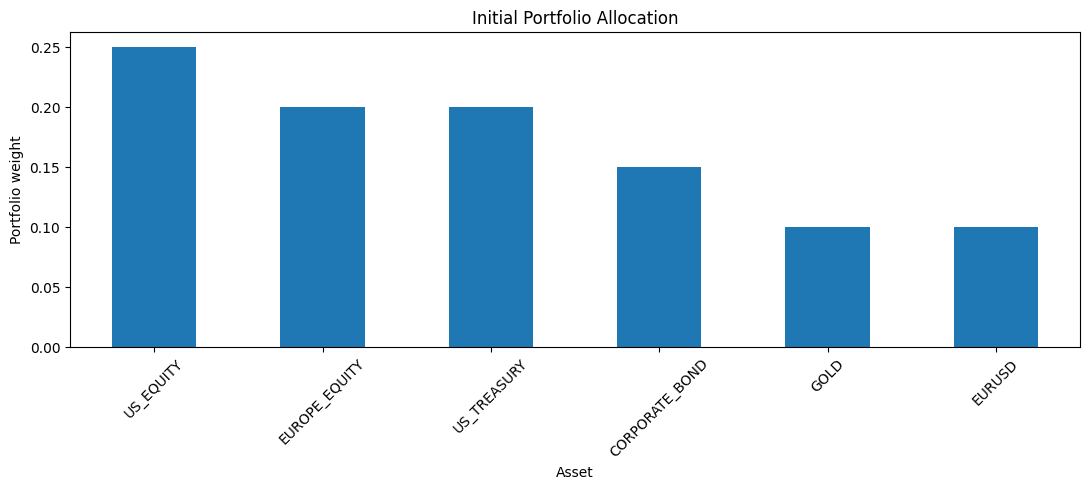

In [ ]:
portfolio_weights.sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(11, 5),
    title="Initial Portfolio Allocation",
)

plt.xlabel("Asset")
plt.ylabel("Portfolio weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Évolution de la valeur du portefeuille

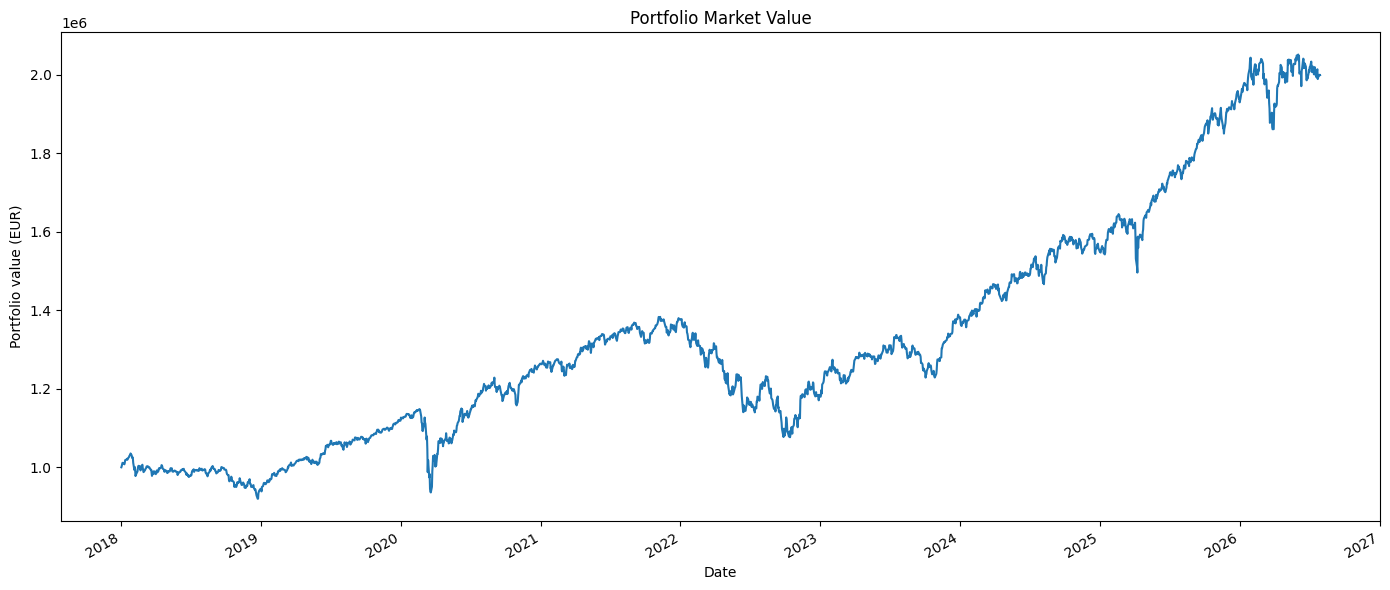

In [ ]:
portfolio_market_value.plot(
    figsize=(14, 6),
    title="Portfolio Market Value",
)

plt.xlabel("Date")
plt.ylabel(
    f"Portfolio value ({REPORTING_CURRENCY})"
)
plt.tight_layout()
plt.show()

### Interpretation

The portfolio market value reflects the combined effect of market movements across all positions.

Changes in the portfolio value are driven by:

- variations in equity markets;
- movements in interest-rate-sensitive instruments;
- changes in corporate bond prices;
- commodity price movements;
- foreign-exchange fluctuations.

### P&L quotidien

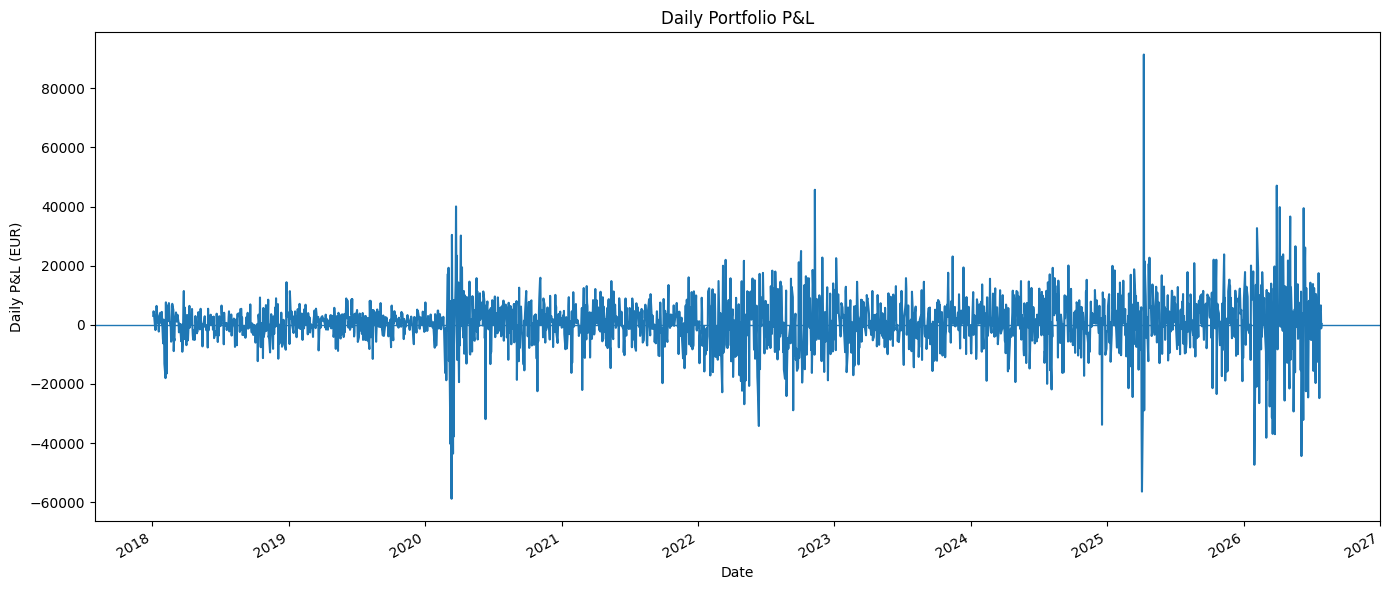

In [ ]:
portfolio_daily_pnl.plot(
    figsize=(14, 6),
    title="Daily Portfolio P&L",
)

plt.axhline(
    y=0,
    linewidth=1,
)

plt.xlabel("Date")
plt.ylabel(
    f"Daily P&L ({REPORTING_CURRENCY})"
)
plt.tight_layout()
plt.show()

### P&L cumulé

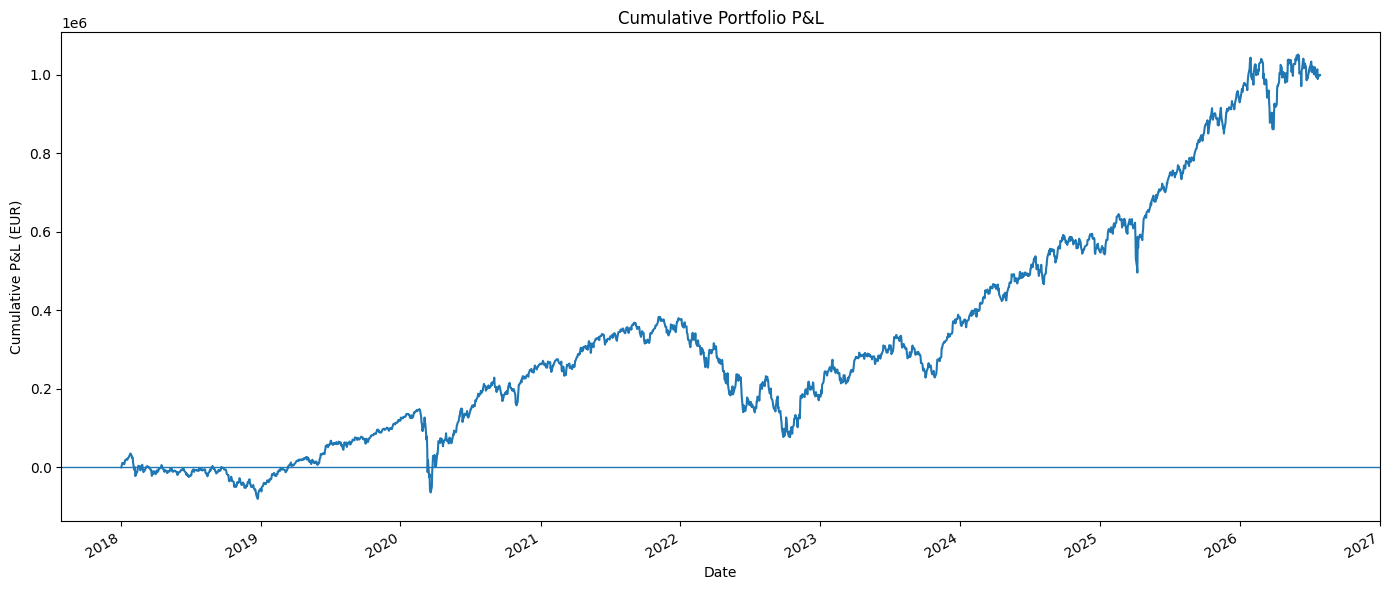

In [ ]:
portfolio_cumulative_pnl.plot(
    figsize=(14, 6),
    title="Cumulative Portfolio P&L",
)

plt.axhline(
    y=0,
    linewidth=1,
)

plt.xlabel("Date")
plt.ylabel(
    f"Cumulative P&L ({REPORTING_CURRENCY})"
)
plt.tight_layout()
plt.show()

### Contribution cumulée au P&L

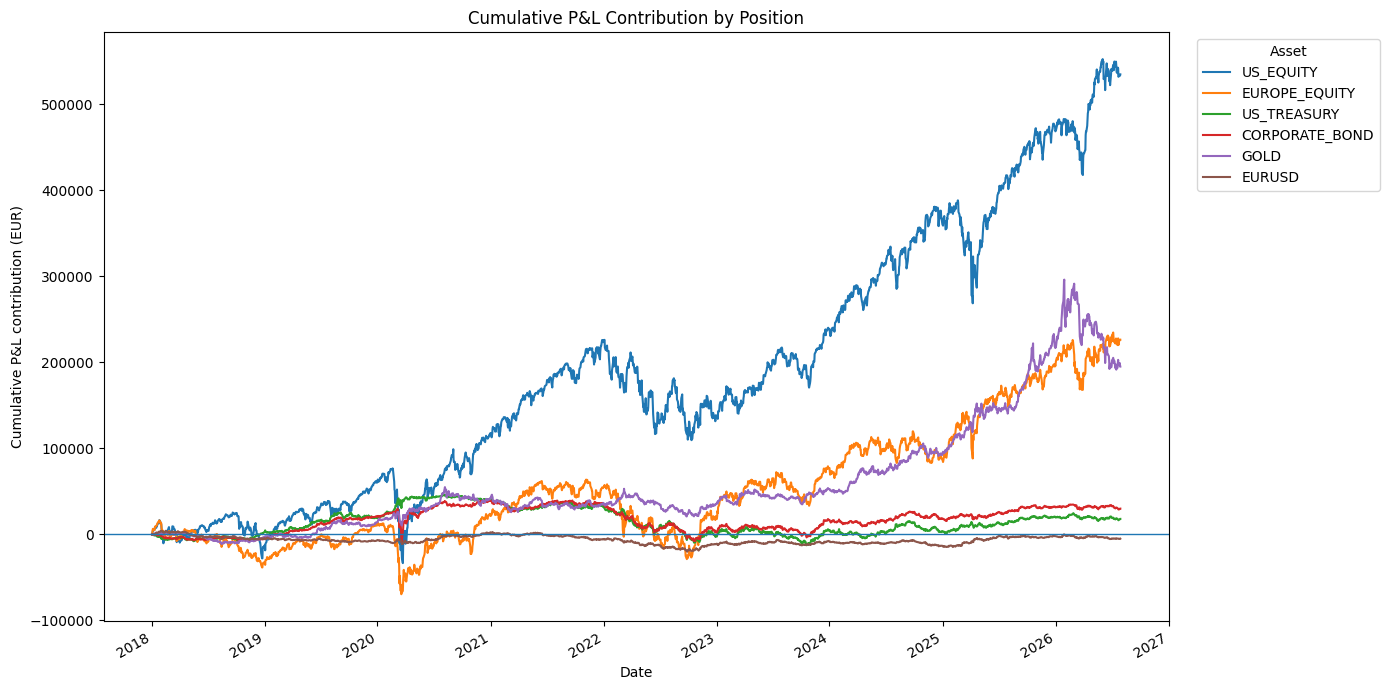

In [ ]:
asset_cumulative_pnl = (
    position_market_values
    - position_market_values.iloc[0]
)

asset_cumulative_pnl.plot(
    figsize=(14, 7),
    title="Cumulative P&L Contribution by Position",
)

plt.axhline(
    y=0,
    linewidth=1,
)

plt.xlabel("Date")
plt.ylabel(
    f"Cumulative P&L contribution "
    f"({REPORTING_CURRENCY})"
)

plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

### Évolution des poids

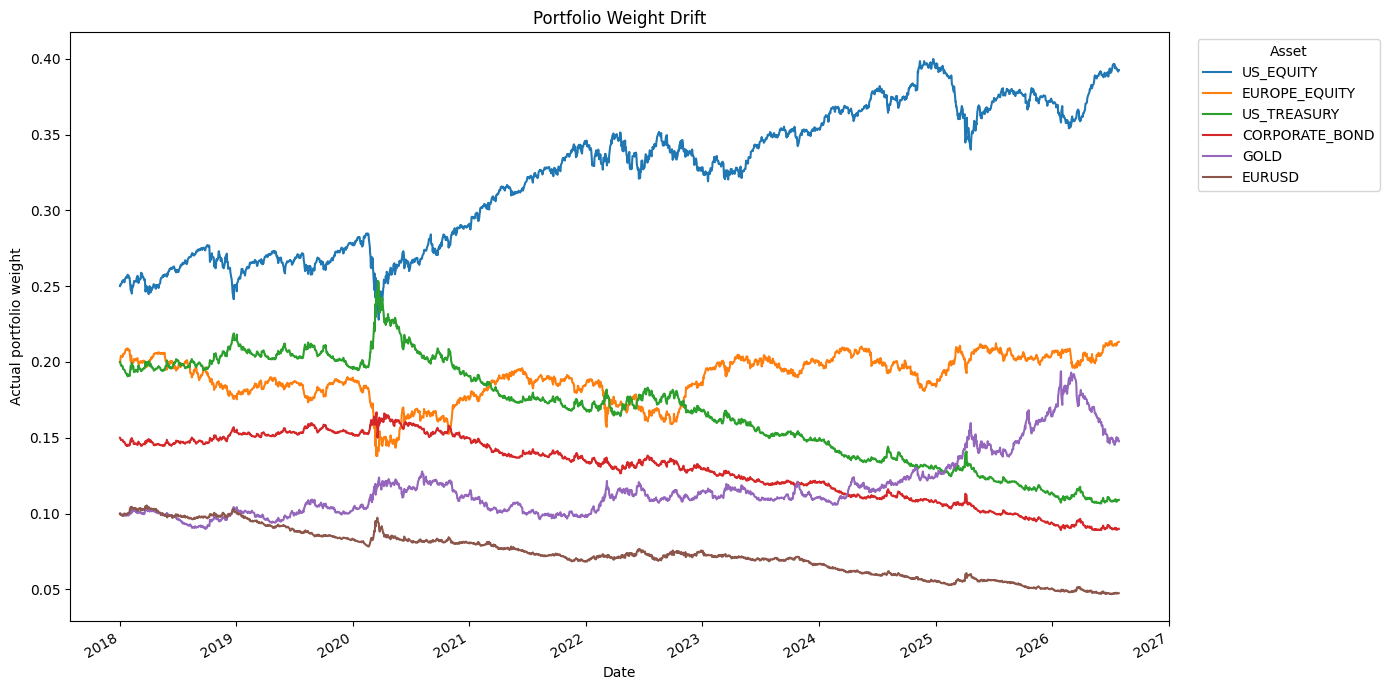

In [ ]:
actual_portfolio_weights.plot(
    figsize=(14, 7),
    title="Portfolio Weight Drift",
)

plt.xlabel("Date")
plt.ylabel("Actual portfolio weight")

plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

## Statistiques du portefeuille

### Fonction de statistiques

In [ ]:
def calculate_portfolio_statistics(
    portfolio_returns: pd.Series,
    daily_pnl: pd.Series,
    portfolio_value: pd.Series,
    trading_days: int = 252,
) -> pd.Series:
    """Calculate key portfolio performance statistics."""

    clean_returns = portfolio_returns.dropna()
    clean_pnl = daily_pnl.dropna()

    if clean_returns.empty:
        raise ValueError(
            "Portfolio returns are empty."
        )

    annualized_return = (
        clean_returns.mean()
        * trading_days
    )

    annualized_volatility = (
        clean_returns.std()
        * np.sqrt(trading_days)
    )

    running_maximum = (
        portfolio_value.cummax()
    )

    drawdown = (
        portfolio_value
        / running_maximum
        - 1
    )

    statistics = pd.Series({
        "initial_portfolio_value":
            portfolio_value.iloc[0],

        "latest_portfolio_value":
            portfolio_value.iloc[-1],

        "total_pnl":
            portfolio_value.iloc[-1]
            - portfolio_value.iloc[0],

        "total_return":
            portfolio_value.iloc[-1]
            / portfolio_value.iloc[0]
            - 1,

        "annualized_return":
            annualized_return,

        "annualized_volatility":
            annualized_volatility,

        "minimum_daily_return":
            clean_returns.min(),

        "maximum_daily_return":
            clean_returns.max(),

        "average_daily_pnl":
            clean_pnl.mean(),

        "daily_pnl_volatility":
            clean_pnl.std(),

        "worst_daily_pnl":
            clean_pnl.min(),

        "best_daily_pnl":
            clean_pnl.max(),

        "maximum_drawdown":
            drawdown.min(),

        "positive_pnl_rate":
            clean_pnl.gt(0).mean(),

        "negative_pnl_rate":
            clean_pnl.lt(0).mean(),

        "number_of_observations":
            len(clean_returns),
    })

    return statistics

### Calculer les statistiques

In [ ]:
portfolio_statistics = (
    calculate_portfolio_statistics(
        portfolio_returns=portfolio_returns,
        daily_pnl=portfolio_daily_pnl,
        portfolio_value=portfolio_market_value,
        trading_days=TRADING_DAYS_PER_YEAR,
    )
)

portfolio_statistics.to_frame("value")

,value
initial_portfolio_value,"1,000,000.000000"
latest_portfolio_value,"1,999,432.663429"
total_pnl,"999,432.663429"
total_return,0.999433
annualized_return,0.083637
annualized_volatility,0.103882
minimum_daily_return,-0.056249
maximum_daily_return,0.061093
average_daily_pnl,447.774491
daily_pnl_volatility,"8,861.569190"


## Meilleurs et pires jours

### Identifier les jours extrêmes

In [ ]:
pnl_ranking = pd.DataFrame({
    "daily_pnl": portfolio_daily_pnl,
    "portfolio_return": portfolio_returns,
}).dropna()

worst_pnl_days = (
    pnl_ranking
    .nsmallest(10, "daily_pnl")
)

best_pnl_days = (
    pnl_ranking
    .nlargest(10, "daily_pnl")
)

print("Worst P&L days")
display(worst_pnl_days)

print("\nBest P&L days")
display(best_pnl_days)

Worst P&L days


,daily_pnl,portfolio_return
date,,
2020-03-12,"-58,860.168697",-0.056249
2025-04-04,"-56,436.476112",-0.035539
2026-01-30,"-47,366.712302",-0.023177
2026-06-05,"-44,412.597777",-0.021688
2020-03-16,"-43,585.649785",-0.042816
2020-03-09,"-40,334.488824",-0.036313
2026-03-03,"-38,214.788943",-0.018833
2020-03-18,"-37,791.384916",-0.038455
2026-03-26,"-37,017.296693",-0.019445



Best P&L days


,daily_pnl,portfolio_return
date,,
2025-04-09,"91,413.550184",0.061093
2026-03-31,"47,065.564992",0.025280
2022-11-10,"45,668.858007",0.040585
2020-03-24,"40,025.814804",0.042116
2026-04-08,"39,789.168930",0.020658
2026-06-11,"39,436.921711",0.020005
2026-05-06,"36,622.549996",0.018297
2026-02-06,"32,687.023794",0.016551
2020-03-13,"30,408.449777",0.030792


### Contribution des positions au pire jour

In [ ]:
worst_day = (
    portfolio_daily_pnl.idxmin()
)

worst_day_contributions = (
    asset_daily_pnl.loc[worst_day]
    .sort_values()
    .to_frame("pnl_contribution")
)

worst_day_contributions[
    "contribution_percentage"
] = (
    worst_day_contributions[
        "pnl_contribution"
    ]
    / portfolio_daily_pnl.loc[worst_day]
)

print(f"Worst P&L date: {worst_day.date()}")
print(
    "Portfolio P&L:",
    f"{portfolio_daily_pnl.loc[worst_day]:,.2f}",
    REPORTING_CURRENCY,
)

worst_day_contributions

Worst P&L date: 2020-03-12
Portfolio P&L: -58,860.17 EUR


,pnl_contribution,contribution_percentage
asset,,
US_EQUITY,"-25,351.715330",0.430711
EUROPE_EQUITY,"-20,347.165233",0.345686
CORPORATE_BOND,"-7,916.909147",0.134504
GOLD,"-4,906.112117",0.083352
EURUSD,-457.808685,0.007778
US_TREASURY,119.541816,-0.002031


## Contribution totale au P&L

### Contribution par actif

In [ ]:
total_asset_pnl_contribution = (
    asset_cumulative_pnl.iloc[-1]
    .sort_values(ascending=False)
    .to_frame("total_pnl_contribution")
)

total_portfolio_pnl = (
    portfolio_cumulative_pnl.iloc[-1]
)

if not np.isclose(total_portfolio_pnl, 0):
    total_asset_pnl_contribution[
        "contribution_percentage"
    ] = (
        total_asset_pnl_contribution[
            "total_pnl_contribution"
        ]
        / total_portfolio_pnl
    )
else:
    total_asset_pnl_contribution[
        "contribution_percentage"
    ] = np.nan

total_asset_pnl_contribution

,total_pnl_contribution,contribution_percentage
asset,,
US_EQUITY,"534,961.360623",0.535265
EUROPE_EQUITY,"226,407.591303",0.226536
GOLD,"195,141.822304",0.195253
CORPORATE_BOND,"29,963.802687",0.029981
US_TREASURY,"18,017.959718",0.018028
EURUSD,"-5,059.873206",-0.005063


In [ ]:
asset_pnl_sum = float(
    total_asset_pnl_contribution[
        "total_pnl_contribution"
    ].sum()
)

assert np.isclose(
    asset_pnl_sum,
    total_portfolio_pnl,
    atol=1e-6,
)

print("Total P&L contribution reconciliation successful.")

Total P&L contribution reconciliation successful.


## Table temporelle finale

### Construire la table principale

In [ ]:
portfolio_timeseries = pd.concat(
    [
        portfolio_market_value,
        portfolio_returns,
        portfolio_daily_pnl,
        portfolio_cumulative_pnl,
    ],
    axis=1,
)

portfolio_timeseries.index.name = "date"

portfolio_timeseries.head()

,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl
date,,,,
2018-01-02,"1,000,000.000000",NaN,NaN,0.000000
2018-01-03,"1,003,014.507203",0.003015,"3,014.507203","3,014.507203"
2018-01-04,"1,007,570.505280",0.004542,"4,555.998077","7,570.505280"
2018-01-05,"1,011,394.086659",0.003795,"3,823.581379","11,394.086659"
2018-01-08,"1,010,643.062040",-0.000743,-751.024618,"10,643.062040"


In [ ]:
portfolio_running_max = (
    portfolio_market_value.cummax()
)

portfolio_drawdown = (
    portfolio_market_value
    / portfolio_running_max
    - 1
)

portfolio_drawdown.name = "drawdown"

portfolio_timeseries = portfolio_timeseries.join(
    portfolio_drawdown
)

portfolio_timeseries["rolling_20d_volatility"] = (
    portfolio_returns
    .rolling(20)
    .std()
    * np.sqrt(TRADING_DAYS_PER_YEAR)
)

portfolio_timeseries["rolling_60d_volatility"] = (
    portfolio_returns
    .rolling(60)
    .std()
    * np.sqrt(TRADING_DAYS_PER_YEAR)
)

portfolio_timeseries.tail()

,portfolio_value,portfolio_return,daily_pnl,cumulative_pnl,drawdown,rolling_20d_volatility,rolling_60d_volatility
date,,,,,,,
2026-07-23,"1,989,509.247349",-0.012318,"-24,813.268222","989,509.247349",-0.030405,0.097974,0.125107
2026-07-24,"1,993,812.306882",0.002163,"4,303.059533","993,812.306882",-0.028308,0.097913,0.125158
2026-07-27,"2,000,370.124522",0.003289,"6,557.817640","1,000,370.124522",-0.025112,0.095153,0.123327
2026-07-28,"1,999,146.618600",-0.000612,"-1,223.505922","999,146.618600",-0.025708,0.093640,0.121809
2026-07-29,"1,999,432.663429",0.000143,286.044829,"999,432.663429",-0.025569,0.093273,0.115696


## Contrôles finaux

### Validation des résultats

In [ ]:
def validate_portfolio_outputs(
    portfolio_timeseries: pd.DataFrame,
    position_market_values: pd.DataFrame,
    asset_daily_pnl: pd.DataFrame,
    actual_weights: pd.DataFrame,
) -> None:
    """Validate the main outputs of Notebook 02."""

    required_columns = {
        "portfolio_value",
        "portfolio_return",
        "daily_pnl",
        "cumulative_pnl",
        "drawdown",
    }

    missing_columns = (
        required_columns
        - set(portfolio_timeseries.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing portfolio time-series columns: "
            f"{sorted(missing_columns)}"
        )

    if position_market_values.empty:
        raise ValueError(
            "Position market values are empty."
        )

    if asset_daily_pnl.empty:
        raise ValueError(
            "Asset P&L contributions are empty."
        )

    if actual_weights.empty:
        raise ValueError(
            "Actual portfolio weights are empty."
        )

    if not np.isfinite(
        position_market_values.to_numpy()
    ).all():
        raise ValueError(
            "Non-finite position values detected."
        )

    weight_sums = actual_weights.sum(axis=1)

    if not np.allclose(
        weight_sums,
        1.0,
        atol=1e-8,
    ):
        raise ValueError(
            "Actual portfolio weights do not sum to one."
        )

    if portfolio_timeseries[
        "portfolio_value"
    ].le(0).any():
        raise ValueError(
            "Non-positive portfolio values detected."
        )

    print("Portfolio output validation successful.")


validate_portfolio_outputs(
    portfolio_timeseries=portfolio_timeseries,
    position_market_values=position_market_values,
    asset_daily_pnl=asset_daily_pnl,
    actual_weights=actual_portfolio_weights,
)

Portfolio output validation successful.


## Enregistrement des sorties

### Définir les fichiers

In [ ]:
NOTEBOOK_02_OUTPUTS = {
    "portfolio_weights_csv": (
        DATA_PROCESSED_DIR
        / "portfolio_weights.csv"
    ),

    "portfolio_positions_csv": (
        DATA_PROCESSED_DIR
        / "portfolio_positions.csv"
    ),

    "portfolio_timeseries_csv": (
        DATA_PROCESSED_DIR
        / "portfolio_timeseries.csv"
    ),

    "portfolio_timeseries_parquet": (
        DATA_PROCESSED_DIR
        / "portfolio_timeseries.parquet"
    ),

    "position_market_values_parquet": (
        DATA_PROCESSED_DIR
        / "position_market_values.parquet"
    ),

    "asset_pnl_contributions_csv": (
        DATA_PROCESSED_DIR
        / "asset_pnl_contributions.csv"
    ),

    "asset_pnl_contributions_parquet": (
        DATA_PROCESSED_DIR
        / "asset_pnl_contributions.parquet"
    ),

    "actual_portfolio_weights_parquet": (
        DATA_PROCESSED_DIR
        / "actual_portfolio_weights.parquet"
    ),

    "portfolio_statistics_csv": (
        REPORTS_DIR
        / "portfolio_statistics.csv"
    ),

    "worst_pnl_days_csv": (
        REPORTS_DIR
        / "worst_pnl_days.csv"
    ),

    "best_pnl_days_csv": (
        REPORTS_DIR
        / "best_pnl_days.csv"
    ),

    "risk_factor_exposure_csv": (
        REPORTS_DIR
        / "risk_factor_exposure.csv"
    ),

    "total_pnl_contribution_csv": (
        REPORTS_DIR
        / "total_pnl_contribution.csv"
    ),
}

## Manifeste du notebook 2

### Définir les dépendances du notebook 3

In [ ]:
NOTEBOOK_03_DEPENDENCIES = [
    NOTEBOOK_02_OUTPUTS[
        "portfolio_timeseries_parquet"
    ],
    NOTEBOOK_02_OUTPUTS[
        "portfolio_weights_csv"
    ],
    NOTEBOOK_02_OUTPUTS[
        "portfolio_positions_csv"
    ],
    NOTEBOOK_02_OUTPUTS[
        "asset_pnl_contributions_parquet"
    ],
]

### Calculer les empreintes

In [ ]:
portfolio_positions.to_csv(
    NOTEBOOK_02_OUTPUTS["portfolio_positions_csv"]
)

portfolio_weights.to_csv(
    NOTEBOOK_02_OUTPUTS["portfolio_weights_csv"]
)

position_market_values.to_parquet(
    NOTEBOOK_02_OUTPUTS["position_market_values_parquet"]
)

asset_daily_pnl.to_parquet(
    NOTEBOOK_02_OUTPUTS["asset_pnl_contributions_parquet"]
)

portfolio_timeseries.to_csv(
    NOTEBOOK_02_OUTPUTS["portfolio_timeseries_csv"]
)

portfolio_timeseries.to_parquet(
    NOTEBOOK_02_OUTPUTS["portfolio_timeseries_parquet"]
)

notebook_02_hashes = {
    file_path.name: calculate_file_hash(file_path)
    for file_path in NOTEBOOK_03_DEPENDENCIES
}

notebook_02_hashes

{'portfolio_timeseries.parquet': '8ad5b57011be9abe8da80b2ac2a055acb3a344a7fd88ae806c42aa8252f2f5f1',
 'portfolio_weights.csv': '30770211096b759793962fb08d9985f0005e49940526f38bf1a86b5f187fdfd8',
 'portfolio_positions.csv': '69b82696d83bef987a317995150b37f56c8319f8aa00bac280ca75fcc830ba3c',
 'asset_pnl_contributions.parquet': 'a9b4889091733ab17b0afc2c379d13e23fbd14b1e6dec7e59b1659dd013055a1'}

### Créer le manifeste

In [ ]:
NOTEBOOK_02_MANIFEST_PATH = (
    CONFIG_DIR
    / "notebook_02_manifest.json"
)

generation_time = datetime.now(
    timezone.utc
).isoformat()

notebook_02_manifest = {
    "pipeline_name":
        "Market Risk Analytics Platform",

    "pipeline_version":
        notebook_01_manifest[
            "pipeline_version"
        ],

    "producer_notebook":
        "02_portfolio_and_pnl_analysis.ipynb",

    "upstream_notebook":
        notebook_01_manifest[
            "producer_notebook"
        ],

    "upstream_manifest":
        str(
            NOTEBOOK_01_FILES["manifest"]
            .relative_to(PROJECT_ROOT)
        ),

    "generated_at_utc":
        generation_time,

    "portfolio_name":
        PORTFOLIO_NAME,

    "reporting_currency":
        REPORTING_CURRENCY,

    "initial_portfolio_value":
        INITIAL_PORTFOLIO_VALUE,

    "initial_valuation_date":
        str(INITIAL_VALUATION_DATE.date()),

    "portfolio_assets":
        portfolio_weights.index.tolist(),

    "target_weights":
        {
            asset: float(weight)
            for asset, weight
            in portfolio_weights.items()
        },

    "number_of_positions":
        int(len(portfolio_positions)),

    "number_of_observations":
        int(
            portfolio_returns
            .dropna()
            .shape[0]
        ),

    "actual_start_date":
        str(
            portfolio_timeseries.index
            .min()
            .date()
        ),

    "actual_end_date":
        str(
            portfolio_timeseries.index
            .max()
            .date()
        ),

    "latest_portfolio_value":
        float(
            portfolio_market_value.iloc[-1]
        ),

    "total_pnl":
        float(
            portfolio_cumulative_pnl.iloc[-1]
        ),

    "notebook_03_dependencies": [
        str(
            file_path.relative_to(PROJECT_ROOT)
        )
        for file_path
        in NOTEBOOK_03_DEPENDENCIES
    ],

    "file_hashes":
        notebook_02_hashes,

    "status":
        "SUCCESS",
}

with open(
    NOTEBOOK_02_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        notebook_02_manifest,
        manifest_file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "Notebook 02 manifest saved to:",
    NOTEBOOK_02_MANIFEST_PATH,
)

Notebook 02 manifest saved to: /content/drive/MyDrive/market-risk-analytics/config/notebook_02_manifest.json


## Validation des dépendances du notebook 3

### Vérifier les fichiers

In [ ]:
def validate_notebook_02_outputs(
    required_files: list[Path],
    manifest_path: Path,
) -> None:
    """Validate all Notebook 02 outputs required by Notebook 03."""

    missing_files = [
        file_path
        for file_path in required_files
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Notebook 02 failed to create: "
            f"{missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            f"Empty output files detected: {empty_files}"
        )

    if not manifest_path.exists():
        raise FileNotFoundError(
            "Notebook 02 manifest was not created."
        )

    with open(
        manifest_path,
        "r",
        encoding="utf-8",
    ) as manifest_file:
        manifest = json.load(
            manifest_file
        )

    if manifest.get("status") != "SUCCESS":
        raise RuntimeError(
            "Notebook 02 manifest does not report SUCCESS."
        )

    print("All Notebook 02 dependencies are valid.")
    print("Notebook 03 can now be executed.")


validate_notebook_02_outputs(
    required_files=NOTEBOOK_03_DEPENDENCIES,
    manifest_path=NOTEBOOK_02_MANIFEST_PATH,
)

All Notebook 02 dependencies are valid.
Notebook 03 can now be executed.


### Test de rechargement

### Simuler le chargement par le notebook 3

In [ ]:
reloaded_portfolio_timeseries = (
    pd.read_parquet(
        NOTEBOOK_02_OUTPUTS[
            "portfolio_timeseries_parquet"
        ]
    )
)

reloaded_asset_pnl = pd.read_parquet(
    NOTEBOOK_02_OUTPUTS[
        "asset_pnl_contributions_parquet"
    ]
)

reloaded_positions = pd.read_csv(
    NOTEBOOK_02_OUTPUTS[
        "portfolio_positions_csv"
    ],
    index_col=0,
)

reloaded_weights = pd.read_csv(
    NOTEBOOK_02_OUTPUTS[
        "portfolio_weights_csv"
    ],
    index_col=0,
).squeeze("columns")

assert (
    reloaded_portfolio_timeseries.shape
    == portfolio_timeseries.shape
)

assert (
    reloaded_asset_pnl.shape
    == asset_daily_pnl.shape
)

assert np.isclose(
    reloaded_weights.sum(),
    1.0,
)

print("Notebook 03 loading test successful.")
print(
    "Portfolio time series:",
    reloaded_portfolio_timeseries.shape,
)
print(
    "Asset P&L contributions:",
    reloaded_asset_pnl.shape,
)

Notebook 03 loading test successful.
Portfolio time series: (2233, 7)
Asset P&L contributions: (2233, 6)


## Résumé du notebook

### Tableau récapitulatif

In [ ]:
notebook_02_summary = pd.DataFrame({
    "indicator": [
        "Pipeline status",
        "Portfolio name",
        "Reporting currency",
        "Initial portfolio value",
        "Latest portfolio value",
        "Total P&L",
        "Total return",
        "Annualized volatility",
        "Maximum drawdown",
        "Number of positions",
        "Number of return observations",
        "Files required by Notebook 03",
    ],
    "value": [
        "SUCCESS",
        PORTFOLIO_NAME,
        REPORTING_CURRENCY,
        INITIAL_PORTFOLIO_VALUE,
        portfolio_market_value.iloc[-1],
        portfolio_cumulative_pnl.iloc[-1],
        portfolio_statistics["total_return"],
        portfolio_statistics[
            "annualized_volatility"
        ],
        portfolio_statistics[
            "maximum_drawdown"
        ],
        len(portfolio_positions),
        portfolio_returns.dropna().shape[0],
        len(NOTEBOOK_03_DEPENDENCIES),
    ],
})

notebook_02_summary

,indicator,value
0,Pipeline status,SUCCESS
1,Portfolio name,Global Multi-Asset Risk Portfolio
2,Reporting currency,EUR
3,Initial portfolio value,"1,000,000.000000"
4,Latest portfolio value,"1,999,432.663429"
5,Total P&L,"999,432.663429"
6,Total return,0.999433
7,Annualized volatility,0.103882
8,Maximum drawdown,-0.221661
9,Number of positions,6


## Conclusion

Notebook 02 successfully transformed the market data generated by Notebook 01 into a fully valued multi-asset portfolio.

### Main results

- A diversified portfolio was created across equity, interest-rate, credit, commodity and foreign-exchange risk factors.
- Initial allocations were converted into asset quantities.
- Daily position market values were calculated using a buy-and-hold framework.
- Portfolio value, daily P&L and cumulative P&L were calculated.
- Daily P&L was reconciled against position-level contributions.
- Dynamic portfolio weights and allocation drift were analyzed.
- Exposures were aggregated by market-risk factor.
- The best and worst P&L days were identified.
- Position-level contributions to total P&L were measured.
- Portfolio statistics and drawdowns were generated.
- A dependency manifest was created for Notebook 03.

### Main portfolio assumptions

- The portfolio is initialized with a value of EUR 1,000,000.
- The portfolio follows a buy-and-hold strategy.
- Position quantities remain constant over the analysis period.
- Transaction costs, taxes, funding costs and bid-ask spreads are excluded.
- Instruments are treated as market-risk proxies.
- Currency conversion is simplified at this stage.

### Dependency created for Notebook 03

Notebook 03 must load and validate:

- `data/processed/portfolio_timeseries.parquet`;
- `data/processed/portfolio_weights.csv`;
- `data/processed/portfolio_positions.csv`;
- `data/processed/asset_pnl_contributions.parquet`;
- `config/notebook_02_manifest.json`.

### Next step

Notebook 03 will estimate and compare:

- Historical Value-at-Risk;
- Parametric Value-at-Risk;
- Student-t Value-at-Risk;
- Monte Carlo Value-at-Risk;
- Expected Shortfall;
- rolling risk measures.